# Cyber Security Case Study

### Business Context
With the rapid growth of networked systems and applications, cybersecurity has become a critical concern for organizations. Intrusion Detection Systems (IDS) play a key role in identifying malicious activities and safeguarding network infrastructure by analyzing large volumes of connection-level data.

### Problem Statement
The dataset consists of multiple network traffic records across different types of attacks along with normal activity, with a high number of features and class imbalance. The objective is to build models that can:

- Perform binary classification (normal vs attack)
- Perform multi-class classification (identify specific attack types)

### Expected Outcomes:

- Combine and preprocess multiple datasets, handling class imbalance
- Conduct EDA to understand feature behavior and attack patterns
- Build and compare classification models for both binary and multi-class problems
- Evaluate model performance using appropriate metrics (e.g., accuracy, precision, recall)
- Develop a robust intrusion detection system capable of identifying and classifying network attacks effectively

##### Essential Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier


In [2]:
normal = pd.read_csv(R"C:\Users\Asus\Downloads\ML Data\Data_of_Attack_Back_Normal.csv")
back = pd.read_csv(R"C:\Users\Asus\Downloads\ML Data\Data_of_Attack_Back.csv")
bufferoverflow = pd.read_csv(R"C:\Users\Asus\Downloads\ML Data\Data_of_Attack_Back_BufferOverflow.csv")
ftpwrite = pd.read_csv(R"C:\Users\Asus\Downloads\ML Data\Data_of_Attack_Back_FTPWrite.csv") 
GuessPassword = pd.read_csv(R"C:\Users\Asus\Downloads\ML Data\Data_of_Attack_Back_GuessPassword.csv") 
neptune = pd.read_csv(R"C:\Users\Asus\Downloads\ML Data\Data_of_Attack_Back_Neptune.csv") 
nmap = pd.read_csv(R"C:\Users\Asus\Downloads\ML Data\Data_of_Attack_Back_NMap.csv") 
portsweep = pd.read_csv(R"C:\Users\Asus\Downloads\ML Data\Data_of_Attack_Back_PortSweep.csv") 
rootkit = pd.read_csv(R"C:\Users\Asus\Downloads\ML Data\Data_of_Attack_Back_RootKit.csv") 
satan = pd.read_csv(R"C:\Users\Asus\Downloads\ML Data\Data_of_Attack_Back_Satan.csv")
smurf = pd.read_csv(R"C:\Users\Asus\Downloads\ML Data\Data_of_Attack_Back_Smurf.csv") 

##### Checking if all tables have the same no of columns before appending

In [3]:
normal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576710 entries, 0 to 576709
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   duration                      576710 non-null  float64
 1    protocol_type                576710 non-null  float64
 2    service                      576710 non-null  float64
 3    flag                         576710 non-null  float64
 4    src_bytes                    576710 non-null  float64
 5    dst_bytes                    576710 non-null  float64
 6    land                         576710 non-null  int64  
 7    wrong_fragment               576710 non-null  int64  
 8    urgent                       576710 non-null  float64
 9    hot                          576710 non-null  float64
 10   num_failed_logins            576710 non-null  float64
 11   logged_in                    576710 non-null  float64
 12   num_compromised              576710 non-nul

In [4]:
back.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 968 entries, 0 to 967
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   duration                      968 non-null    float64
 1    protocol_type                968 non-null    int64  
 2    service                      968 non-null    int64  
 3    flag                         968 non-null    float64
 4    src_bytes                    968 non-null    float64
 5    dst_bytes                    968 non-null    float64
 6    land                         968 non-null    int64  
 7    wrong_fragment               968 non-null    int64  
 8    urgent                       968 non-null    int64  
 9    hot                          968 non-null    float64
 10   num_failed_logins            968 non-null    int64  
 11   logged_in                    968 non-null    float64
 12   num_compromised              968 non-null    float64
 13   root

In [5]:
bufferoverflow.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   duration                      30 non-null     float64
 1    protocol_type                30 non-null     int64  
 2    service                      30 non-null     float64
 3    flag                         30 non-null     float64
 4    src_bytes                    30 non-null     float64
 5    dst_bytes                    30 non-null     float64
 6    land                         30 non-null     int64  
 7    wrong_fragment               30 non-null     int64  
 8    urgent                       30 non-null     int64  
 9    hot                          30 non-null     float64
 10   num_failed_logins            30 non-null     int64  
 11   logged_in                    30 non-null     float64
 12   num_compromised              30 non-null     float64
 13   root_s

In [6]:
nmap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1554 entries, 0 to 1553
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   duration                      1554 non-null   int64  
 1    protocol_type                1554 non-null   float64
 2    service                      1554 non-null   float64
 3    flag                         1554 non-null   float64
 4    src_bytes                    1554 non-null   float64
 5    dst_bytes                    1554 non-null   float64
 6    land                         1554 non-null   int64  
 7    wrong_fragment               1554 non-null   int64  
 8    urgent                       1554 non-null   int64  
 9    hot                          1554 non-null   int64  
 10   num_failed_logins            1554 non-null   int64  
 11   logged_in                    1554 non-null   int64  
 12   num_compromised              1554 non-null   int64  
 13   ro

In [7]:
ftpwrite.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   duration                      8 non-null      float64
 1    protocol_type                8 non-null      int64  
 2    service                      8 non-null      float64
 3    flag                         8 non-null      int64  
 4    src_bytes                    8 non-null      float64
 5    dst_bytes                    8 non-null      float64
 6    land                         8 non-null      int64  
 7    wrong_fragment               8 non-null      int64  
 8    urgent                       8 non-null      float64
 9    hot                          8 non-null      float64
 10   num_failed_logins            8 non-null      int64  
 11   logged_in                    8 non-null      float64
 12   num_compromised              8 non-null      float64
 13   root_she

In [8]:
portsweep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964 entries, 0 to 2963
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   duration                      2964 non-null   float64
 1    protocol_type                2964 non-null   float64
 2    service                      2964 non-null   float64
 3    flag                         2964 non-null   float64
 4    src_bytes                    2964 non-null   float64
 5    dst_bytes                    2964 non-null   float64
 6    land                         2964 non-null   int64  
 7    wrong_fragment               2964 non-null   int64  
 8    urgent                       2964 non-null   int64  
 9    hot                          2964 non-null   float64
 10   num_failed_logins            2964 non-null   int64  
 11   logged_in                    2964 non-null   float64
 12   num_compromised              2964 non-null   int64  
 13   ro

In [9]:
rootkit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   duration                      10 non-null     float64
 1    protocol_type                10 non-null     float64
 2    service                      10 non-null     float64
 3    flag                         10 non-null     int64  
 4    src_bytes                    10 non-null     float64
 5    dst_bytes                    10 non-null     float64
 6    land                         10 non-null     int64  
 7    wrong_fragment               10 non-null     int64  
 8    urgent                       10 non-null     float64
 9    hot                          10 non-null     float64
 10   num_failed_logins            10 non-null     float64
 11   logged_in                    10 non-null     float64
 12   num_compromised              10 non-null     float64
 13   root_sh

In [10]:
smurf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3007 entries, 0 to 3006
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   duration                      3007 non-null   int64  
 1    protocol_type                3007 non-null   float64
 2    service                      3007 non-null   float64
 3    flag                         3007 non-null   int64  
 4    src_bytes                    3007 non-null   float64
 5    dst_bytes                    3007 non-null   int64  
 6    land                         3007 non-null   int64  
 7    wrong_fragment               3007 non-null   float64
 8    urgent                       3007 non-null   int64  
 9    hot                          3007 non-null   int64  
 10   num_failed_logins            3007 non-null   int64  
 11   logged_in                    3007 non-null   int64  
 12   num_compromised              3007 non-null   int64  
 13   ro

In [11]:
neptune.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227228 entries, 0 to 227227
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   duration                      227228 non-null  float64
 1    protocol_type                227228 non-null  int64  
 2    service                      227228 non-null  float64
 3    flag                         227228 non-null  float64
 4    src_bytes                    227228 non-null  float64
 5    dst_bytes                    227228 non-null  float64
 6    land                         227228 non-null  int64  
 7    wrong_fragment               227228 non-null  int64  
 8    urgent                       227228 non-null  int64  
 9    hot                          227228 non-null  int64  
 10   num_failed_logins            227228 non-null  int64  
 11   logged_in                    227228 non-null  float64
 12   num_compromised              227228 non-nul

In [12]:
GuessPassword.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   duration                      53 non-null     float64
 1    protocol_type                53 non-null     int64  
 2    service                      53 non-null     float64
 3    flag                         53 non-null     float64
 4    src_bytes                    53 non-null     float64
 5    dst_bytes                    53 non-null     float64
 6    land                         53 non-null     int64  
 7    wrong_fragment               53 non-null     int64  
 8    urgent                       53 non-null     int64  
 9    hot                          53 non-null     float64
 10   num_failed_logins            53 non-null     float64
 11   logged_in                    53 non-null     float64
 12   num_compromised              53 non-null     int64  
 13   root_s

In [13]:
rootkit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   duration                      10 non-null     float64
 1    protocol_type                10 non-null     float64
 2    service                      10 non-null     float64
 3    flag                         10 non-null     int64  
 4    src_bytes                    10 non-null     float64
 5    dst_bytes                    10 non-null     float64
 6    land                         10 non-null     int64  
 7    wrong_fragment               10 non-null     int64  
 8    urgent                       10 non-null     float64
 9    hot                          10 non-null     float64
 10   num_failed_logins            10 non-null     float64
 11   logged_in                    10 non-null     float64
 12   num_compromised              10 non-null     float64
 13   root_sh

##### compiling all 11 tables and creating 'attack_type' & 'attack_binary' column as per the problem 
##### Final df = (41 cols (Features) + 2 cols (Target))

In [14]:
dfs = {'normal': normal,'back': back,'bufferoverflow': bufferoverflow,'ftpwrite': ftpwrite,'guesspassword': GuessPassword,'neptune': neptune,
    'nmap': nmap,'rootkit': rootkit,'portsweep': portsweep,'satan': satan,'smurf': smurf}

In [15]:
for name, df in dfs.items():
    df['attack_type'] = name # multiclass target
    df['attack_binary'] = 'normal' if name == 'normal' else 'attack' # binary target

In [16]:
compiled_table = pd.concat(dfs.values(), ignore_index=True)

In [17]:
compiled_table.columns = compiled_table.columns.str.strip()

In [18]:
compiled_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817551 entries, 0 to 817550
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     817551 non-null  float64
 1   protocol_type                817551 non-null  float64
 2   service                      817551 non-null  float64
 3   flag                         817551 non-null  float64
 4   src_bytes                    817551 non-null  float64
 5   dst_bytes                    817551 non-null  float64
 6   land                         817551 non-null  int64  
 7   wrong_fragment               817551 non-null  float64
 8   urgent                       817551 non-null  float64
 9   hot                          817551 non-null  float64
 10  num_failed_logins            817551 non-null  float64
 11  logged_in                    817551 non-null  float64
 12  num_compromised              817551 non-null  float64
 13 

In [19]:
compiled_table.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,attack_binary
0,0.0,0.0,0.0,0.0,0.00215,0.45076,0,0.0,0.0,0.0,...,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,normal,normal
1,0.0,0.0,0.0,0.0,0.00162,0.04528,0,0.0,0.0,0.0,...,0.1,0.0,0.100,0.0,0.0,0.0,0.0,0.0,normal,normal
2,0.0,0.0,0.0,0.0,0.00236,0.01228,0,0.0,0.0,0.0,...,0.1,0.0,0.050,0.0,0.0,0.0,0.0,0.0,normal,normal
3,0.0,0.0,0.0,0.0,0.00233,0.02032,0,0.0,0.0,0.0,...,0.1,0.0,0.033,0.0,0.0,0.0,0.0,0.0,normal,normal
4,0.0,0.0,0.0,0.0,0.00239,0.00486,0,0.0,0.0,0.0,...,0.1,0.0,0.025,0.0,0.0,0.0,0.0,0.0,normal,normal


#### Fixing the column data types as per the case study brief & splitting categorical and numerical cols

- Nominal:  Protocol_type(2), Service(3), Flag(4) 
- Binary: Land(7), logged_in(12), root_shell(14), su_attempted(15), is_host_login(21), is_guest_login(22) 
- Numeric: Duration(1), src_bytes(5), dst_bytes(6), wrong_fragment(8), urgent(9), hot(10), 
  num_failed_logins(11), num_compromised(13), num_root(16), num_file_creations(17), 
  num_shells(18), num_access_files(19), num_outbound_cmds(20), count(23), srv_count(24), 
  error_rate(25), srv_serror_rate(26),  rerror_rate(27),srv_rerror_rate(28),  same_srv_rate(29), 
  diff_srv_rate(30), srv_diff_host_rate(31), dst_host_count(32), dst_host_srv_count(33), 
  dst_host_same_srv_rate(34), dst_host_diff_srv_rate(35),  dst_host_same_src_port_rate(36),  
  dst_host_srv_diff_host_rate(37), dst_host_serror_rate(38),  dst_host_srv_serror_rate(39),  
  dst_host_rerror_rate(40), dst_host_srv_rerror_rate(41) 

In [20]:
nominal_cols = ['protocol_type', 'service', 'flag']

binary_cols = ['land', 'logged_in', 'root_shell','su_attempted', 'is_host_login', 'is_guest_login']

numeric_cols = ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment','urgent', 'hot', 'num_failed_logins', 'num_compromised','num_root',
                'num_file_creations', 'num_shells','num_access_files', 'num_outbound_cmds', 'count','srv_count', 'serror_rate', 
                'srv_error_rate','rerror_rate', 'srv_rerror_rate', 'same_srv_rate','diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
                'dst_host_srv_count', 'dst_host_same_srv_rate','dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
                'dst_host_srv_diff_host_rate', 'dst_host_serror_rate','dst_host_srv_serror_rate', 'dst_host_rerror_rate',
                'dst_host_srv_rerror_rate']

In [21]:
compiled_table[nominal_cols] = compiled_table[nominal_cols].astype('category')

In [22]:
compiled_table[binary_cols] = compiled_table[binary_cols].astype('int')

In [23]:
compiled_table[numeric_cols] = compiled_table[numeric_cols].astype('float')

In [24]:
compiled_table.dtypes

duration                        float64
protocol_type                  category
service                        category
flag                           category
src_bytes                       float64
dst_bytes                       float64
land                              int64
wrong_fragment                  float64
urgent                          float64
hot                             float64
num_failed_logins               float64
logged_in                         int64
num_compromised                 float64
root_shell                        int64
su_attempted                      int64
num_root                        float64
num_file_creations              float64
num_shells                      float64
num_access_files                float64
num_outbound_cmds               float64
is_host_login                     int64
is_guest_login                    int64
count                           float64
srv_count                       float64
serror_rate                     float64


In [25]:
compiled_table.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,attack_binary
0,0.0,0.0,0.0,0.0,0.00215,0.45076,0,0.0,0.0,0.0,...,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,normal,normal
1,0.0,0.0,0.0,0.0,0.00162,0.04528,0,0.0,0.0,0.0,...,0.1,0.0,0.100,0.0,0.0,0.0,0.0,0.0,normal,normal
2,0.0,0.0,0.0,0.0,0.00236,0.01228,0,0.0,0.0,0.0,...,0.1,0.0,0.050,0.0,0.0,0.0,0.0,0.0,normal,normal
3,0.0,0.0,0.0,0.0,0.00233,0.02032,0,0.0,0.0,0.0,...,0.1,0.0,0.033,0.0,0.0,0.0,0.0,0.0,normal,normal
4,0.0,0.0,0.0,0.0,0.00239,0.00486,0,0.0,0.0,0.0,...,0.1,0.0,0.025,0.0,0.0,0.0,0.0,0.0,normal,normal


In [26]:
compiled_table[nominal_cols].nunique()

protocol_type     3
service          67
flag             11
dtype: int64

In [27]:
compiled_table['protocol_type'].value_counts()

protocol_type
0.00    776566
0.01     35402
0.02      5583
Name: count, dtype: int64

In [28]:
compiled_table['service'].value_counts()

service
0.00    462331
0.12    181678
0.01     53979
0.02     31806
0.14     21976
         ...  
0.38         5
0.64         2
0.65         2
0.67         2
0.63         1
Name: count, Length: 67, dtype: int64

In [29]:
compiled_table['flag'].value_counts()

flag
0.00    570819
0.07    202685
0.05     38579
0.06      2541
0.08      2020
0.02       331
0.10       298
0.09       122
0.01        97
0.04        40
0.03        19
Name: count, dtype: int64

In [30]:
compiled_table.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,817551.000000,817551.000000,817551.000000,817551.0,8.175510e+05,817551.000000,817551.000000,817551.000000,817551.0,817551.000000,...,817551.000000,817551.000000,817551.000000,817551.000000,817551.000000,817551.000000,817551.000000,817551.000000,817551.000000,817551.000000
mean,0.000877,0.004961,0.024862,0.0,3.669496e-07,0.000003,0.002456,0.000016,0.0,0.000275,...,0.166868,0.161651,0.066795,0.003380,0.006148,0.001683,0.024865,0.024852,0.005372,0.005279
std,0.026636,0.033235,0.066635,0.0,3.317904e-04,0.000805,0.041470,0.001618,0.0,0.010338,...,0.102058,0.111642,0.043421,0.008557,0.017460,0.003708,0.043062,0.043151,0.021920,0.022070
min,0.000000,0.000000,0.000000,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,...,0.054000,0.017000,0.007000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.002170,0.003670,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,...,0.255000,0.255000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.002990,0.019690,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,...,0.255000,0.255000,0.100000,0.006000,0.003000,0.002000,0.014000,0.003000,0.000000,0.000000
max,1.000000,1.000000,1.000000,0.0,3.000000e-01,0.500000,1.000000,0.500000,0.0,1.000000,...,0.255000,0.255000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000


###### Since there are columns with only 0s dropping them as 1 > they are useless for further ML process and are not informative at all for the model to learn patterns from

In [31]:
zero_var_cols = [col for col in compiled_table.columns if compiled_table[col].nunique() == 1]

In [32]:
zero_var_cols  #7 cols dropped

['land',
 'logged_in',
 'root_shell',
 'su_attempted',
 'num_outbound_cmds',
 'is_host_login',
 'is_guest_login']

In [33]:
compiled_table.drop(columns=zero_var_cols, inplace=True)    

In [34]:
compiled_table #final df = 34 cols (Features) + 2 cols (Target) = 36 cols

,duration,protocol_type,service,flag,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,attack_binary
0,0.0,0.00,0.00,0.0,0.00215,0.45076,0.0,0.0,0.0,0.0,...,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,normal,normal
1,0.0,0.00,0.00,0.0,0.00162,0.04528,0.0,0.0,0.0,0.0,...,0.100,0.000,0.100,0.0,0.0,0.0,0.0,0.0,normal,normal
2,0.0,0.00,0.00,0.0,0.00236,0.01228,0.0,0.0,0.0,0.0,...,0.100,0.000,0.050,0.0,0.0,0.0,0.0,0.0,normal,normal
3,0.0,0.00,0.00,0.0,0.00233,0.02032,0.0,0.0,0.0,0.0,...,0.100,0.000,0.033,0.0,0.0,0.0,0.0,0.0,normal,normal
4,0.0,0.00,0.00,0.0,0.00239,0.00486,0.0,0.0,0.0,0.0,...,0.100,0.000,0.025,0.0,0.0,0.0,0.0,0.0,normal,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817546,0.0,0.02,0.09,0.0,0.01032,0.00000,0.0,0.0,0.0,0.0,...,0.098,0.001,0.098,0.0,0.0,0.0,0.0,0.0,smurf,attack
817547,0.0,0.02,0.09,0.0,0.01032,0.00000,0.0,0.0,0.0,0.0,...,0.099,0.001,0.099,0.0,0.0,0.0,0.0,0.0,smurf,attack
817548,0.0,0.02,0.09,0.0,0.01032,0.00000,0.0,0.0,0.0,0.0,...,0.099,0.001,0.099,0.0,0.0,0.0,0.0,0.0,smurf,attack
817549,0.0,0.02,0.09,0.0,0.01032,0.00000,0.0,0.0,0.0,0.0,...,0.100,0.001,0.100,0.0,0.0,0.0,0.0,0.0,smurf,attack


In [35]:
numeric = compiled_table.select_dtypes('float')

In [36]:
numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817551 entries, 0 to 817550
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     817551 non-null  float64
 1   src_bytes                    817551 non-null  float64
 2   dst_bytes                    817551 non-null  float64
 3   wrong_fragment               817551 non-null  float64
 4   urgent                       817551 non-null  float64
 5   hot                          817551 non-null  float64
 6   num_failed_logins            817551 non-null  float64
 7   num_compromised              817551 non-null  float64
 8   num_root                     817551 non-null  float64
 9   num_file_creations           817551 non-null  float64
 10  num_shells                   817551 non-null  float64
 11  num_access_files             817551 non-null  float64
 12  count                        817551 non-null  float64
 13 

In [37]:
def continuous_summary(x):
    total_n = x.shape[0] #total rows
    total_miss = x.isna().sum() #total missings
    miss_perc = total_miss/total_n * 100 #missing %
    min_val = min(x)
    P1 = x.quantile(0.01)
    P25 = x.quantile(0.25)
    P50 = x.quantile(0.50)
    P75 = x.quantile(0.75)
    P90 = x.quantile(0.90)
    P99 = x.quantile(0.99)
    P100 = x.quantile(1)
    max_val = max(x)
    IQR = P75 - P25
    uc = P25 - 1.5 * IQR
    lc = P75 + 1.5 * IQR

    return pd.Series([x.dtype, x.nunique(), x.count(), total_n, total_miss, miss_perc, x.sum(), x.mean(), x.var(), x.std(), 
                    lc, uc, min_val, P1, P25, P50, P75, P90, P99, P100, max_val],
                     index = ['dtype', 'unique','n', 'total', 'total missing', 'missing%', 'sum', 'mean', 'var', 'std', 'UC', 'LC', 'min', 
                              'P1', 'P25', 'P50', 'P75', 'P90', 'P99', 'P100', 'max_val'])

In [38]:
numeric.apply(continuous_summary)

,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,num_root,num_file_creations,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
unique,918,5908,18399,2,5,11,6,11,11,11,...,256,256,101,101,101,68,101,97,101,101
n,817551,817551,817551,817551,817551,817551,817551,817551,817551,817551,...,817551,817551,817551,817551,817551,817551,817551,817551,817551,817551
total,817551,817551,817551,817551,817551,817551,817551,817551,817551,817551,...,817551,817551,817551,817551,817551,817551,817551,817551,817551,817551
total missing,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
missing%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sum,716.8347,4056.18442,20326.03324,0.3,2.1,2007.7,12.8,224.9,1195.7,232.5,...,136423.302,132158.195,54608.021,2763.32,5026.182,1375.607,20328.601,20317.676,4392.049,4315.787
mean,0.000877,0.004961,0.024862,0.0,0.000003,0.002456,0.000016,0.000275,0.001463,0.000284,...,0.166868,0.161651,0.066795,0.00338,0.006148,0.001683,0.024865,0.024852,0.005372,0.005279
var,0.000709,0.001105,0.00444,0.0,0.000001,0.00172,0.000003,0.000107,0.00101,0.000138,...,0.010416,0.012464,0.001885,0.000073,0.000305,0.000014,0.001854,0.001862,0.00048,0.000487
std,0.026636,0.033235,0.066635,0.000332,0.000805,0.04147,0.001618,0.010338,0.031777,0.011742,...,0.102058,0.111642,0.043421,0.008557,0.01746,0.003708,0.043062,0.043151,0.02192,0.02207


In [39]:
numeric.skew()

duration                        35.073175
src_bytes                       20.369346
dst_bytes                        7.203229
wrong_fragment                 904.185269
urgent                         428.837195
hot                             20.529222
num_failed_logins              154.803907
num_compromised                 70.025146
num_root                        25.086467
num_file_creations              71.981607
num_shells                      72.538663
num_access_files                26.209255
count                            1.704558
srv_count                       10.564927
serror_rate                      1.167887
srv_error_rate                   1.162258
rerror_rate                      3.960633
srv_rerror_rate                  4.001453
same_srv_rate                   -0.964930
diff_srv_rate                    8.004127
srv_diff_host_rate               2.887212
dst_host_count                  -0.493123
dst_host_srv_count              -0.487615
dst_host_same_srv_rate          -0

In [40]:
numeric = numeric.apply( lambda x: x.clip(lower = x.quantile(0.01),upper = x.quantile(0.99)))

In [41]:
numeric.skew()

duration                       7.690391
src_bytes                      6.451287
dst_bytes                      3.694022
wrong_fragment                 0.000000
urgent                         0.000000
hot                            0.000000
num_failed_logins              0.000000
num_compromised                0.000000
num_root                       0.000000
num_file_creations             0.000000
num_shells                     0.000000
num_access_files               0.000000
count                          1.453788
srv_count                      4.413109
serror_rate                    1.167887
srv_error_rate                 1.162258
rerror_rate                    3.960633
srv_rerror_rate                4.001453
same_srv_rate                 -0.964698
diff_srv_rate                  6.059840
srv_diff_host_rate             2.887212
dst_host_count                -0.493123
dst_host_srv_count            -0.487615
dst_host_same_srv_rate        -0.657298
dst_host_diff_srv_rate         4.044389


In [42]:
text = compiled_table.select_dtypes('category')

In [43]:
text.describe()

,protocol_type,service,flag
count,817551.0,817551.0,817551.0
unique,3.0,67.0,11.0
top,0.0,0.0,0.0
freq,776566.0,462331.0,570819.0


In [44]:
text = pd.get_dummies(text, columns = ['protocol_type', 'service', 'flag'], drop_first = True)

In [45]:
text = text.astype('int')
text

,protocol_type_0.01,protocol_type_0.02,service_0.01,service_0.02,service_0.03,service_0.04,service_0.05,service_0.06,service_0.07,service_0.08,...,flag_0.01,flag_0.02,flag_0.03,flag_0.04,flag_0.05,flag_0.06,flag_0.07,flag_0.08,flag_0.09,flag_0.1
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817546,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
817547,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
817548,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
817549,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Data Compilation & Splitting

In [46]:
text.index

RangeIndex(start=0, stop=817551, step=1)

In [47]:
numeric.index

RangeIndex(start=0, stop=817551, step=1)

In [48]:
x = pd.concat([numeric, text], axis=1)
x

,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,num_root,num_file_creations,...,flag_0.01,flag_0.02,flag_0.03,flag_0.04,flag_0.05,flag_0.06,flag_0.07,flag_0.08,flag_0.09,flag_0.1
0,0.0,0.00215,0.309345,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0.00162,0.045280,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0.0,0.00236,0.012280,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0.0,0.00233,0.020320,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0.00239,0.004860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817546,0.0,0.01032,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
817547,0.0,0.01032,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
817548,0.0,0.01032,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
817549,0.0,0.01032,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


#### Model 1 - Binary Classification -> attack_binary (target col)

In [49]:
y_binary = compiled_table['attack_binary']

In [50]:
print(x.shape)
print(y_binary.shape)

(817551, 109)
(817551,)


In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y_binary,test_size=0.2,stratify=y_binary,random_state=232)

In [52]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [53]:
model = LogisticRegression(class_weight= 'balanced')

In [54]:
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [55]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [56]:
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9972065928689376
Test Accuracy: 0.9971989652072337


In [57]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     48168
           1       1.00      1.00      1.00    115343

    accuracy                           1.00    163511
   macro avg       1.00      1.00      1.00    163511
weighted avg       1.00      1.00      1.00    163511



##### The model performs extremely well across both classes (0,1 or normal, attack) with very high precision, recall, and F1-scores indicating that it is able to correctly classify observations while keeping both false positives and false negatives very low.


In [58]:
cm = confusion_matrix(y_test, test_pred)
print(cm)

[[ 47915    253]
 [   205 115138]]


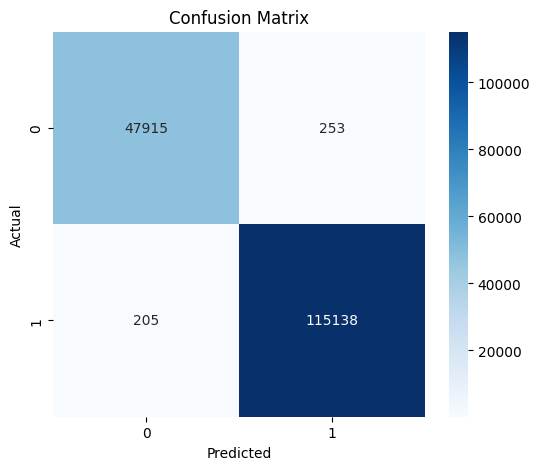

In [59]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

##### The confusion matrix further confirms this performance, with most predictions concentrated along the diagonal (correct predictions) and only a very small number of errors/wrong predictions.

#### Model 2 - Multi-class Classification -> attack_type (target col)

In [60]:
y_multi = compiled_table['attack_type']

In [61]:
print(x.shape)
print(y_multi.shape)

(817551, 109)
(817551,)


In [62]:
y_multi.value_counts()  #Imbalanced Class distribution

attack_type
normal            576710
neptune           227228
satan               5019
smurf               3007
portsweep           2964
nmap                1554
back                 968
guesspassword         53
bufferoverflow        30
rootkit               10
ftpwrite               8
Name: count, dtype: int64

In [63]:
X_train, X_test, y_train, y_test = train_test_split(x,y_multi,test_size=0.2,random_state=232,stratify=y_multi)

In [64]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [65]:
rf = RandomForestClassifier(n_estimators=80,max_depth=15,random_state=232,n_jobs=-1,class_weight='balanced_subsample')

In [66]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [67]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

In [68]:
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9999816524983182
Test Accuracy: 0.9998960314596571


In [69]:
#Converting classes back to text for readability 
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(test_pred)

In [70]:
print(classification_report(y_test_text, y_pred_text))  #Precision and Recall for - Rootkit is 0 due to severe class imbalance (2 samples) it is missclassified for all of its samples

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                precision    recall  f1-score   support

          back       1.00      1.00      1.00       194
bufferoverflow       1.00      0.83      0.91         6
      ftpwrite       1.00      1.00      1.00         1
 guesspassword       1.00      0.91      0.95        11
       neptune       1.00      1.00      1.00     45446
          nmap       1.00      1.00      1.00       311
        normal       1.00      1.00      1.00    115342
     portsweep       1.00      0.99      0.99       593
       rootkit       0.00      0.00      0.00         2
         satan       1.00      0.99      1.00      1004
         smurf       1.00      1.00      1.00       601

      accuracy                           1.00    163511
     macro avg       0.91      0.88      0.90    163511
  weighted avg       1.00      1.00      1.00    163511



C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [71]:
cm = confusion_matrix(y_test_text, y_pred_text)
print(cm)

[[   194      0      0      0      0      0      0      0      0      0
       0]
 [     0      5      0      0      0      0      1      0      0      0
       0]
 [     0      0      1      0      0      0      0      0      0      0
       0]
 [     0      0      0     10      0      0      1      0      0      0
       0]
 [     0      0      0      0  45446      0      0      0      0      0
       0]
 [     0      0      0      0      0    310      0      0      0      1
       0]
 [     0      0      0      0      0      0 115342      0      0      0
       0]
 [     0      0      0      0      0      1      2    589      0      1
       0]
 [     0      0      0      0      0      0      2      0      0      0
       0]
 [     0      0      0      0      0      0      6      2      0    996
       0]
 [     0      0      0      0      0      0      0      0      0      0
     601]]


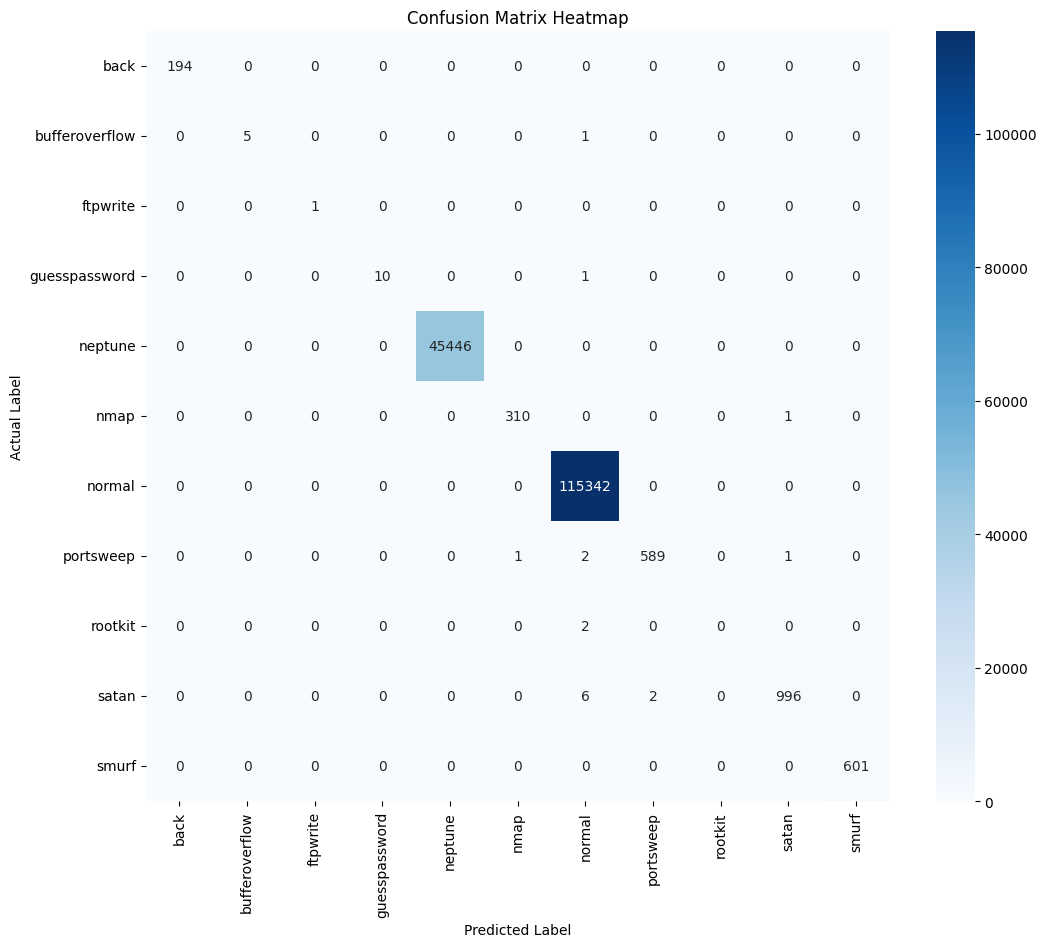

In [72]:
labels = sorted(list(set(y_test_text)))

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(12, 10))

sns.heatmap(cm_df,annot=True,fmt='d',cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Heatmap')

plt.show()

##### Further confusion matrix has revealed that minority class - rootkit was classified as normal for all its present samples 2.This is the biggest weakness of this dataset - extremely few training examples for minority classes therefore, - model is unable to learn meaningful patterns.
##### Model is excellent for detetcting normal and non-rare attacks but when it comes to rare attacks - performs very poorly.
